У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install darts

In [ ]:
!pip install pytorch-lightning torch

In [ ]:
!pip install "darts[torch]"

In [ ]:
!pip install statsforecast

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import sklearn as sk
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf
from darts import TimeSeries, concatenate
from darts.utils.statistics import check_seasonality
from darts.models import NaiveSeasonal, NaiveDrift, XGBModel, ExponentialSmoothing, ARIMA, AutoARIMA, Prophet, RNNModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from statsforecast.models import Naive
from darts.utils.utils import ModelMode, SeasonalityMode



1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv.zip to train.csv (1).zip


In [ ]:
# 1
df = pd.read_csv("train.csv.zip")

In [ ]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
# 3
df['date'] = pd.to_datetime(df['date'])

In [ ]:
# 4
df = df.set_index('date')

In [ ]:
# 5
df.head(10)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


#%% md
Висновок: немає пропущених значень, усі числові значення.


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



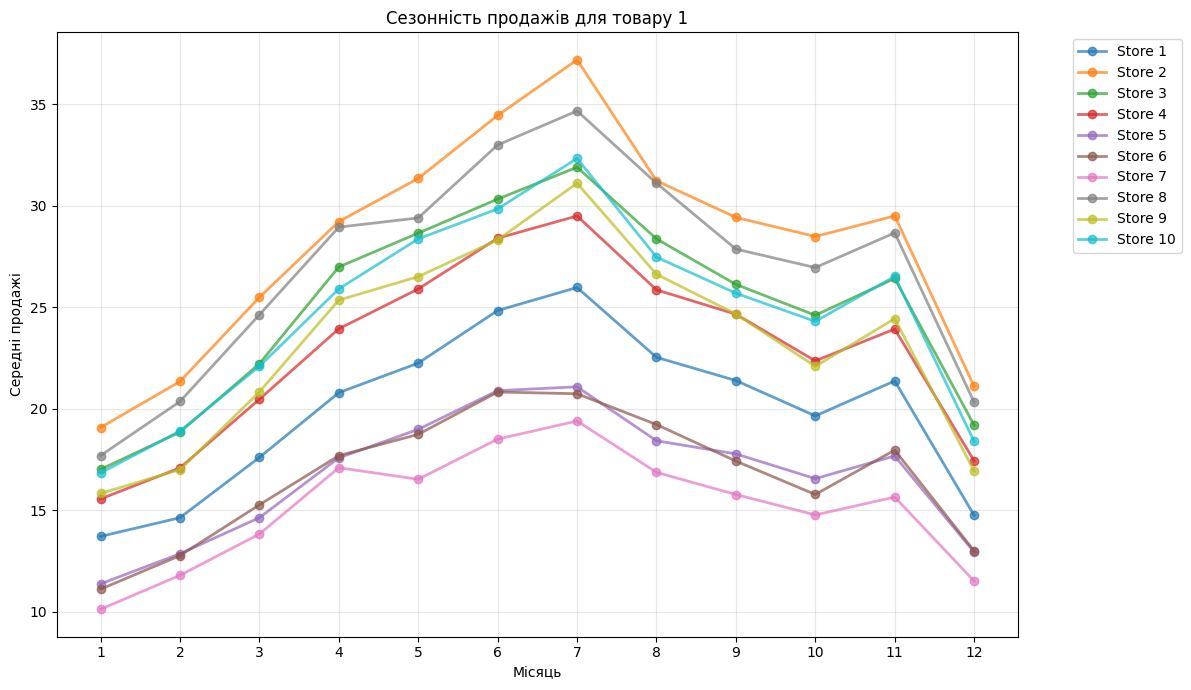

In [ ]:
# add month
df['month'] = df.index.month
item_id = 1
df_item = df[df['item'] == item_id]
df_month = (
    df_item
    .groupby(['month', 'store'])['sales']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 7))

for store in sorted(df_month['store'].unique()):
    subset = df_month[df_month['store'] == store]

    plt.plot(
        subset['month'],
        subset['sales'],
        marker='o',
        linewidth=2,
        alpha=0.7,
        label=f'Store {store}'
    )

plt.title(f'Сезонність продажів для товару {item_id}')
plt.xlabel('Місяць')
plt.ylabel('Середні продажі')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#%% md
Продажі змінюються протягом року. Найвищі вони влітку (приблизно червень–липень), а найнижчі — на початку та в кінці року. Ця поведінка однакова для всіх магазинів.


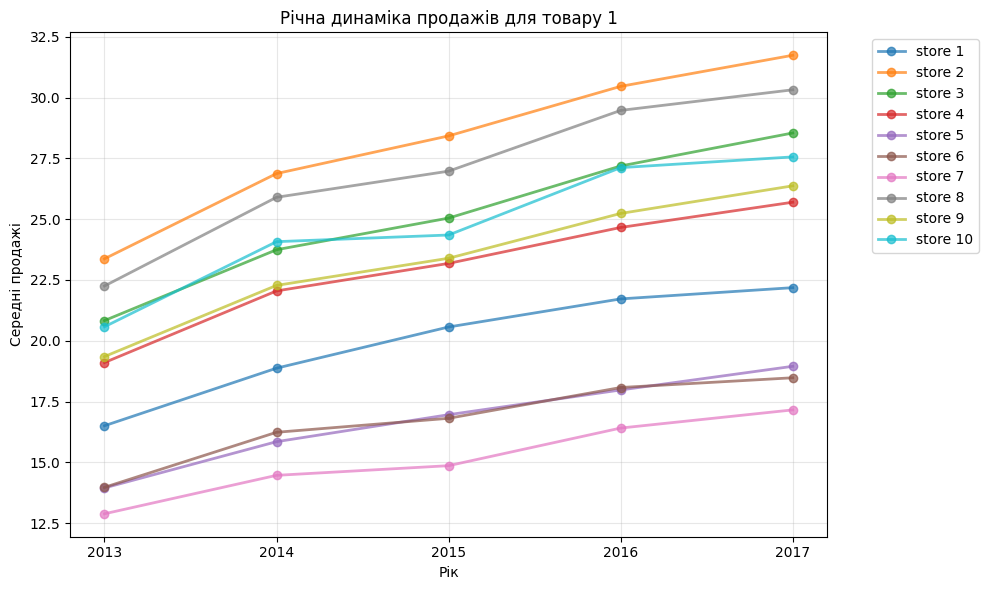

In [ ]:
# add a year
df['year'] = df.index.year
item_id = 1
df_item = df[df['item'] == item_id].copy()

df_year = (
    df_item
    .groupby(['year', 'store'])['sales']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for store in sorted(df_year['store'].unique()):
    subset = df_year[df_year['store'] == store]
    plt.plot(
        subset['year'],
        subset['sales'],
        marker='o',
        linewidth=2,
        alpha=0.7,
        label=f'store {store}'
    )

plt.title(f'Річна динаміка продажів для товару {item_id}')
plt.xlabel('Рік')
plt.ylabel('Середні продажі')
plt.xticks(sorted(df_year['year'].unique()))
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Продажі кожного року потроху зростають. Усі магазини поводяться схоже: якщо в одному продажі ростуть, то і в інших теж. Просто рівень продажів у них різний.

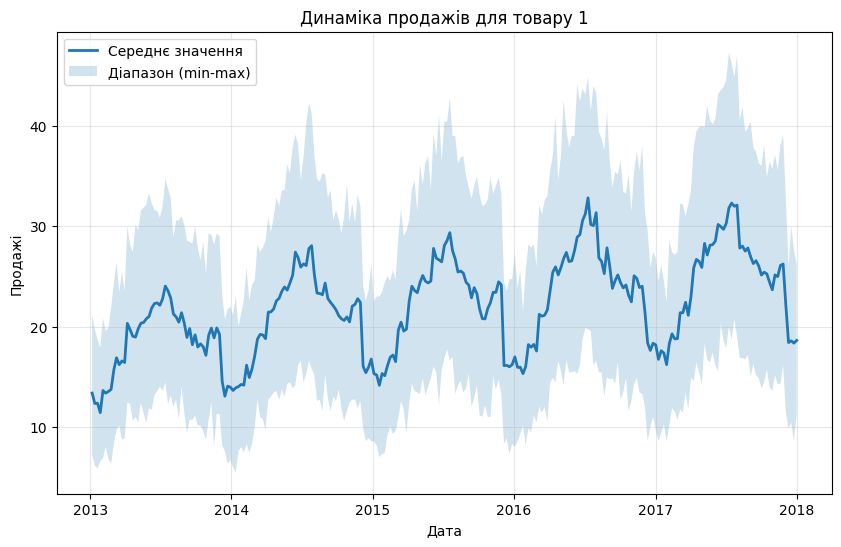

In [ ]:
df_stats = (
    df_item
    .groupby(df_item.index)['sales']
    .agg(['mean', 'min', 'max'])
    .reset_index()
)
df_stats = df_stats.set_index('date').resample('W').mean().reset_index()

plt.figure(figsize=(10, 6))

# mean
plt.plot(
    df_stats['date'],
    df_stats['mean'],
    linewidth=2,
    label='Середнє значення'
)

# range
plt.fill_between(
    df_stats['date'],
    df_stats['min'],
    df_stats['max'],
    alpha=0.2,
    label='Діапазон (min-max)'
)

plt.title(f'Динаміка продажів для товару {item_id}')
plt.xlabel('Дата')
plt.ylabel('Продажі')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#%% md
Продажі постійно коливаються (то ростуть, то падають), але при цьому загальний рівень з часом трохи підвищується. Різниця між магазинами є, але вона не дуже велика і стабільна.



3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [ ]:
df_one = df[(df['item'] == 1) & (df['store'] == 1)].copy()
df_one = df_one.sort_index()

In [ ]:
decomposition = seasonal_decompose(
    df_one['sales'],
    model='additive',
    period=365
)

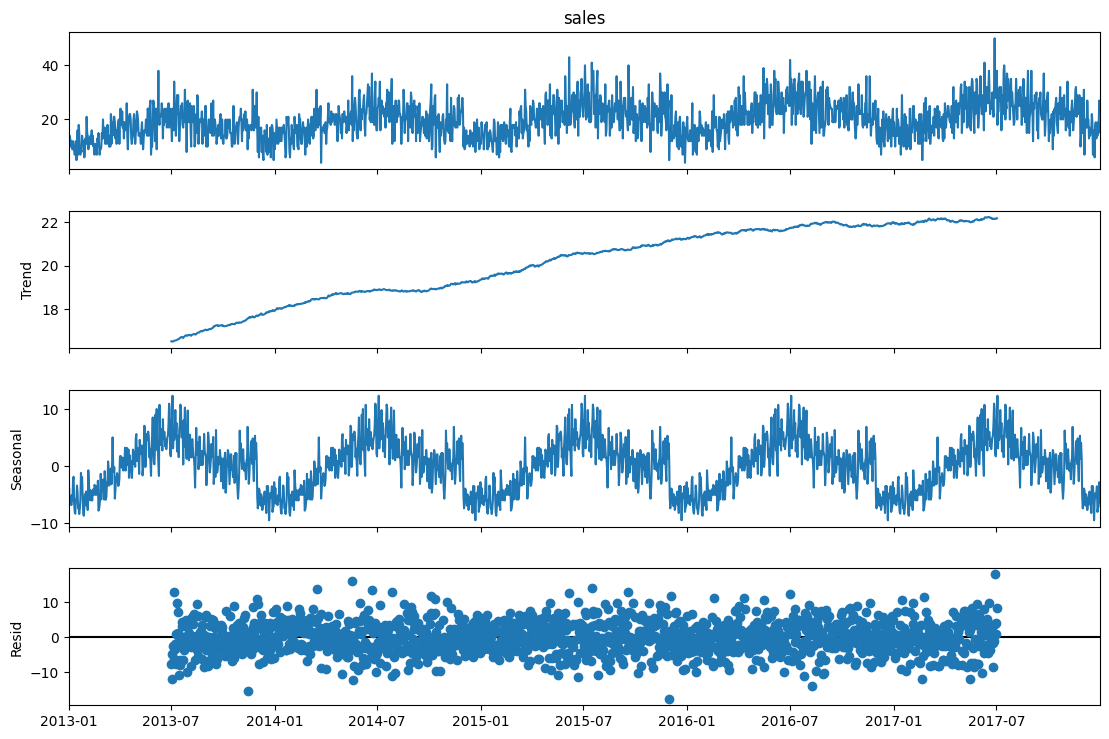

In [ ]:
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

#%% md
Для аналізу було вибрано ряд продажів товару 1 у магазині 1. Декомпозицію виконано за адитивною моделлю з бібліотекою statsmodels. Візуалізація показала, що в ряді є тренд, сезонність і залишки. Тренд відображає загальну зміну продажів у часі, сезонна — повторювані коливання, а залишки — шум, який не пояснюється трендом і сезонністю. Щоденні дані шумні, тому їх краще згладжувати. Місячні та річні вже більш зрозумілі. Розділення на тренд, сезонність і залишки допомагає краще побачити структуру даних. Можна привести ряд до стаціонарності.


4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [ ]:
series = TimeSeries.from_series(df_one['sales'])
series

,sales
date,
2013-01-01,13.0
2013-01-02,11.0
2013-01-03,14.0
2013-01-04,13.0
2013-01-05,10.0
...,...
2017-12-27,14.0
2017-12-28,19.0
2017-12-29,15.0


<Axes: xlabel='date'>

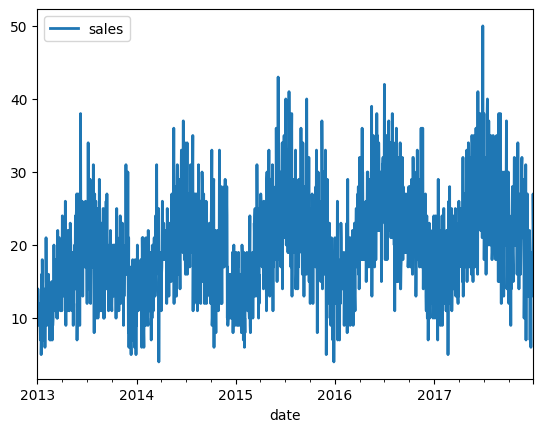

In [ ]:
series.plot()

#%% md
Дані мають сезонність, легкий зростаючий тренд і містять шум.



5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

In [ ]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))

<Axes: xlabel='date'>

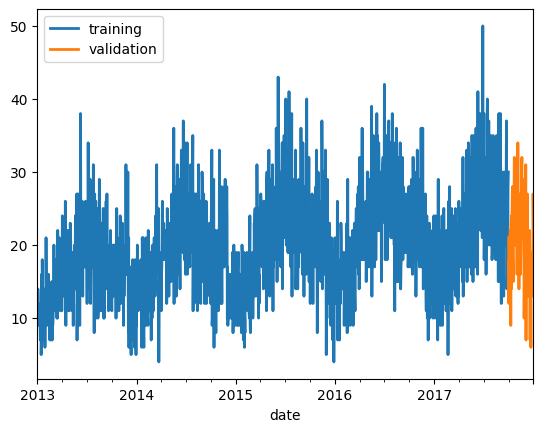

In [ ]:
train.plot(label = 'training')
val.plot(label = 'validation')

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

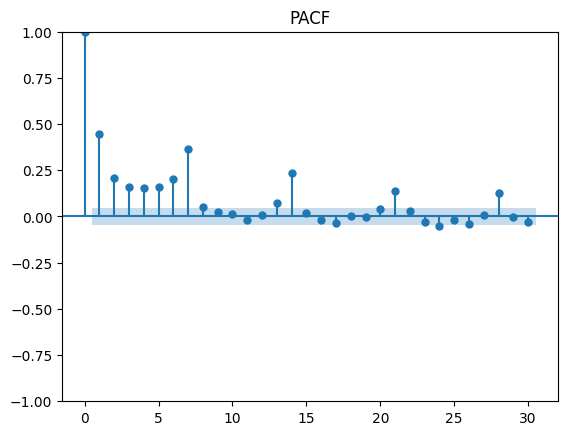

In [ ]:
series_pd = pd.Series(
    series.values().flatten(),
    index = series.time_index
)


plot_pacf(series_pd, lags=30)
plt.title('PACF')
plt.show()

#%% md
Hайбільш значущим є лаг 1, що означає сильну залежність від попереднього дня. Також спостерігаються піки на лагах 7, 14, 21 і 28, що свідчить про наявність тижневої сезонності.


7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [ ]:
is_seasonal, period = check_seasonality(train)
print(is_seasonal, period)

True 7


8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

<Axes: xlabel='date'>

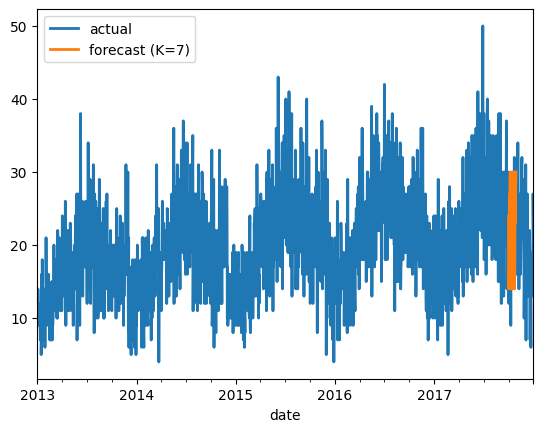

In [ ]:
seasonal_model = NaiveSeasonal(K=7)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(28)
series.plot(label = 'actual')
seasonal_forecast.plot(label = 'forecast (K=7)')

<Axes: xlabel='date'>

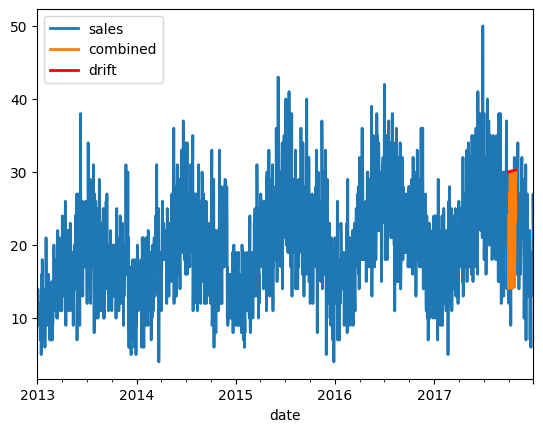

In [ ]:
drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(28)

combined_forecast = drift_forecast + seasonal_forecast - train.last_value()


series.plot()
combined_forecast.plot(label = 'combined')
drift_forecast.plot(label = 'drift', color = 'red')

#%% md
Сезонність є і дорівнює 7, а тренду майже не видно.


9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [ ]:
print(f'MAPE for the combined seasonal + naive drift:{mape(series, combined_forecast):.2f}%.')

MAPE for the combined seasonal + naive drift:29.55%.


#%% md
Помилка 29.55%




10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [ ]:
def make_date_covariates(ts: TimeSeries) -> TimeSeries:
    quarter   = datetime_attribute_timeseries(ts, attribute="quarter")
    dayofweek = datetime_attribute_timeseries(ts, attribute="dayofweek")
    month     = datetime_attribute_timeseries(ts, attribute="month")
    return quarter.stack(dayofweek).stack(month)

train_cov = make_date_covariates(train)
val_cov   = make_date_covariates(val)
all_cov   = concatenate([train_cov, val_cov])

In [ ]:
# scaling
scaler = Scaler()
train_scaled = scaler.fit_transform(train)
val_scaled   = scaler.transform(val)

In [ ]:
modelXGB = XGBModel(
    lags=30,
    lags_past_covariates=7,
    output_chunk_length=28,
    n_estimators=100,
    random_state=42
)

In [ ]:
modelXGB.fit(train_scaled, past_covariates=train_cov)

XGBModel(lags=30, lags_past_covariates=7, lags_future_covariates=None, output_chunk_length=28, output_chunk_shift=0, add_encoders=None, likelihood=None, quantiles=None, random_state=42, multi_models=True, use_static_covariates=True, n_estimators=100)

In [ ]:
xgb_pred = modelXGB.predict(n=28, past_covariates=all_cov)
xgb_pred = scaler.inverse_transform(xgb_pred)

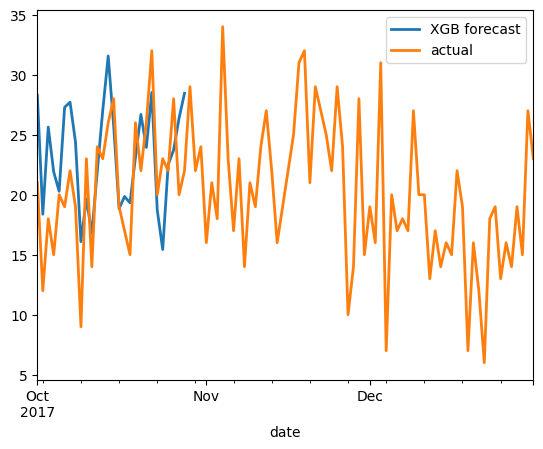

In [ ]:
xgb_pred.plot(label="XGB forecast")
val.plot(label="actual")
plt.legend()
plt.show()

In [ ]:
xgb_mape = mape(val, xgb_pred)
print(f"MAPE for XGBModel: {xgb_mape:.2f}%")

MAPE for XGBModel: 23.56%


У цій молелі якість прогнозу вище, ніж в наївних моделях.

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

In [ ]:
from darts.utils.utils import SeasonalityMode
model_es = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE,
    seasonal=SeasonalityMode.ADDITIVE,
    seasonal_periods=7
)

In [ ]:
model_es.fit(train)

ExponentialSmoothing(trend=ModelMode.ADDITIVE, damped=False, seasonal=SeasonalityMode.ADDITIVE, seasonal_periods=7, error=add, random_errors=None, random_state=None, kwargs=None)

In [ ]:
es_pred = model_es.predict(len(val))

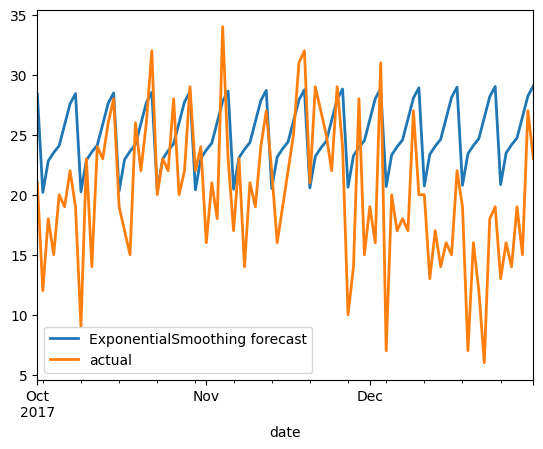

In [ ]:
es_pred.plot(label = "ExponentialSmoothing forecast")
val.plot(label='actual')
plt.legend()
plt.show()

In [ ]:
es_mape = mape(val, es_pred)
print(f'MAPE: {es_mape:.2f}%')

MAPE: 39.01%


Тут помилка поки що найвища -- 39%.

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

In [ ]:
model_arima = ARIMA(p=7, d=1, q=1)

In [ ]:
model_arima.fit(train)

ARIMA(p=7, d=1, q=1, seasonal_order=(0, 0, 0, 0), trend=None, random_state=None, add_encoders=None)

In [ ]:
arima_pred = model_arima.predict(len(val))

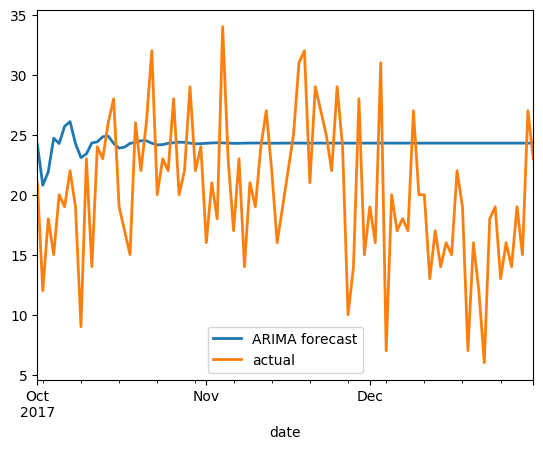

In [ ]:
arima_pred.plot(label='ARIMA forecast')
val.plot(label='actual')
plt.legend()
plt.show()

In [ ]:
arima_mape = mape(val, arima_pred)
print(f'MAPE for ARIMA: {arima_mape:.2f}%')

MAPE for ARIMA: 39.53%


Тут теж помилка майже 40%

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

In [ ]:
model_auto_arima = AutoARIMA()

In [ ]:
model_auto_arima.fit(train)

AutoARIMA(add_encoders=None, quantiles=None, random_state=None)

In [ ]:
auto_arima_pred = model_auto_arima.predict(len(val))

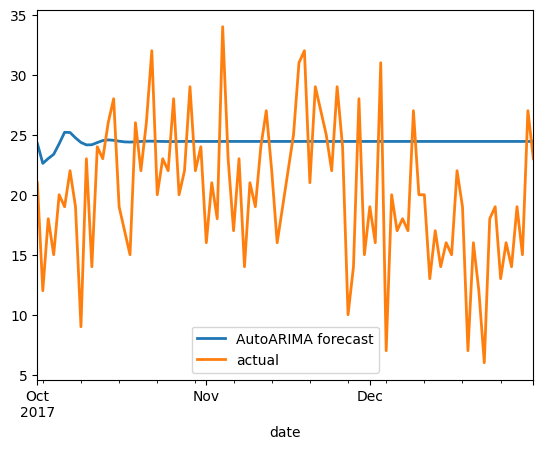

In [ ]:
auto_arima_pred.plot(label = 'AutoARIMA forecast')
val.plot(label = 'actual')
plt.legend()
plt.show()

In [ ]:
auto_arima_mape = mape(val, auto_arima_pred)
print(f'MAPE for AutoARIMA: {auto_arima_mape:.2f}%')

MAPE for AutoARIMA: 40.29%


Через автоматичний підбір параметрів помилка ще вище.

14. Натренуйте модель Prophet та зробіть висновок про її якість.

In [ ]:
model_prop = Prophet()

In [ ]:
model_prop.fit(train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet(add_seasonalities=None, add_regressor_configs=None, country_holidays=None, cap=None, floor=None, add_encoders=None, random_state=None, suppress_stdout_stderror=True)

In [ ]:
prop_forecast = model_prop.predict(len(val))

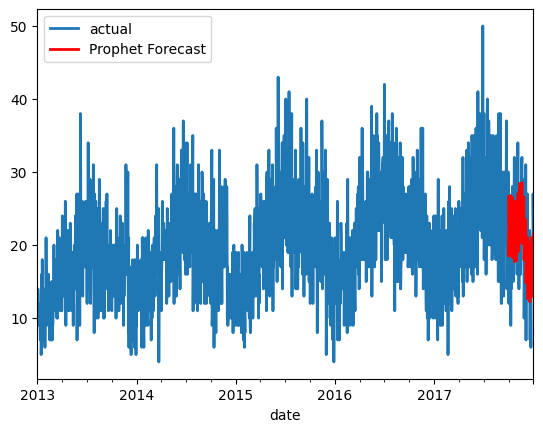

In [ ]:
series.plot(label='actual')
prop_forecast.plot(label='Prophet Forecast', color = 'red')
plt.legend()
plt.show()

In [ ]:
prop_mape = mape(val, prop_forecast)
print(f'MAPE for Prophet: {prop_mape:.2f}%')

MAPE for Prophet: 23.80%


У Пропет помилка 23%

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

In [ ]:
rnn_model = RNNModel(
    model = 'LSTM',
    input_chunk_length = 30,
    training_length = 60,
    n_epochs = 50,
    random_state = 42
    )

In [ ]:
rnn_model.fit(train_scaled)
rnn_pred = rnn_model.predict(len(val))
rnn_pred = scaler.inverse_transform(rnn_pred)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 2.8 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
2.8 K     Trainable params
0         Non-trainable params
2.8 K     Total params
0.011     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

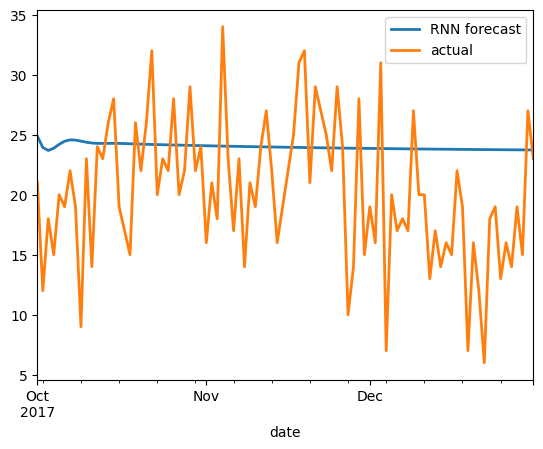

In [ ]:
rnn_pred.plot(label = 'RNN forecast')
val.plot(label = 'actual')
plt.legend()
plt.show()

In [ ]:
rnn_mape = mape(val, rnn_pred)
print(f'MAPE for RNN: {rnn_mape:.2f}%')

MAPE for RNN: 38.71%


Помилка майже 39%, ще пробувала фітити на тренувальному наборі, а не на train_scaled, резульата був 41% приблизно. Залишаю варіант з train_scaled.

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

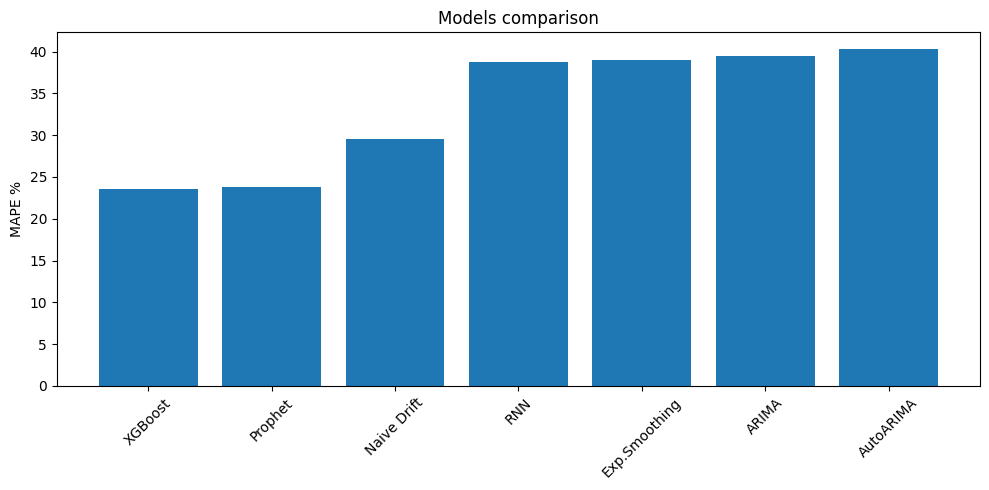

In [ ]:
# models comparison
models = ['XGBoost', 'Prophet', 'Naive Drift', 'RNN', 'Exp.Smoothing', 'ARIMA', 'AutoARIMA']
mapes = [23.56, 23.80, 29.55, 38.71, 39.01, 39.53, 40.29]

plt.figure(figsize=(10, 5))
plt.bar(models, mapes)
plt.ylabel('MAPE %')
plt.title('Models comparison')
plt.xticks(rotation = 45)
plt.tight_layout()

historical forecasts: 100%|██████████| 1/1 [00:00<00:00, 32.94it/s]


MAPE = 1.55%


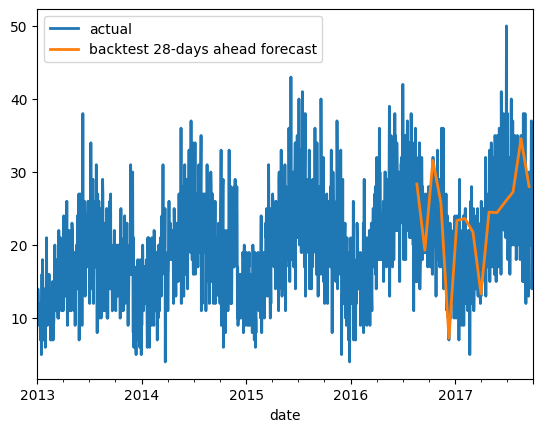

In [ ]:
hfc_params = {
    "series": train_scaled,
    "past_covariates": train_cov,
    "start": 0.75,
    "forecast_horizon": 28,
    "stride": 28,
    "retrain": False,
    "verbose": True,
}

historical_fcast = modelXGB.historical_forecasts(
    last_points_only=True,
    **hfc_params
)

historical_fcast = scaler.inverse_transform(historical_fcast)

train.plot(label="actual")
historical_fcast.plot(label="backtest 28-days ahead forecast")
print(f"MAPE = {mape(train, historical_fcast):.2f}%")

Всю варіантивність не вгадали, але виглядає непогано!

Дуже хороший результат.

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

Якраз XGBoost  можна використати, щоб навчати одночасно на всіх рядах.